#***Microproyecto 2 - Interpretación y análisis de información textual para la identificación de relaciones semánticas con los Objetivos de Desarrollo Sostenibles (ODS)***
###Omar Dario Diaz H.
###Diego Andres Burbano A.

##**1. Carga de librerias**

In [41]:
!python -m spacy download es_core_news_sm
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 60.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [42]:
import os
import pandas as pd
import numpy as np
import nltk
import spacy
import re
import cv2
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
import random

from google.colab import drive
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import RegexpTokenizer
from scipy.stats import randint, uniform
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost.sklearn import XGBClassifier
from gensim.models import Word2Vec, KeyedVectors
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [43]:
# Descarga de NTLK las stopwords en idioma español y carga en spaC
nltk.download('stopwords')
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **2. Carga y preparación de los datos**

Se cargan el set de datos y se realiza una primera revisión del mismo:


In [44]:
from IPython.display import clear_output
clear_output()
drive.mount('/content/drive', force_remount=True)

#Ruta Local Omar B.
#os.chdir('/content/drive/MyDrive/ColabNotebooks/MaestriaUniandesColabs/ML_No_Supervisado/Micro_proyecto2')


# Ruta Local Diego B.
os.chdir('/content/drive/MyDrive/datos')

Mounted at /content/drive


In [45]:
data_cruda = pd.read_excel('dataset_ODS.xlsx')
data_cruda.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [46]:
data_cruda.shape

(9656, 2)

El set original cuenta con 9656 registros cada uno de ellos con 2 columnas.

Se revisa si el set de datos cuenta con duplicados y/o datos nulos:

In [47]:
#Revisión de duplicados
data_cruda.duplicated().sum()

0

In [48]:
#Revisión de datos nulos
data_cruda.isnull().sum()

,0
textos,0
ODS,0


Se confirma que el set de datos no cuenta con datos duplicados y/o nulos.

Se realiza una exploración de como se encuentra distribuidas las clases de la variable objetivo:

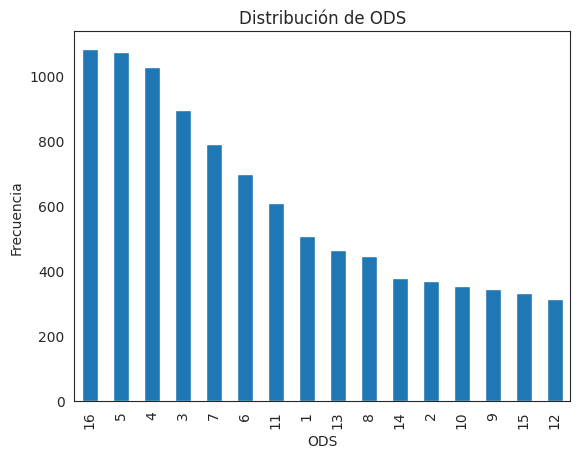

In [49]:
#Exploración de la distribucion de clases
data_cruda['ODS'].value_counts().plot(kind='bar')
plt.title('Distribución de ODS')
plt.xlabel('ODS')
plt.ylabel('Frecuencia')
plt.show()

Observamos la presencia de 16 clases las cuales presentan una distribución no uniforme, presentandose variaciones significativas, superiores al 200%, entre las categorías con mas presencia frente a las menos favorecidas.

Mas adelante a lo largo del proceso de transformación de data y desarrollo de los diferentes modelos, se tomarán las medidas para mitigar los riesgos que puede conllevar la clasificación binaria cuando se presenta un desbalanceo del set.  

Separación de la variable objetivo del set de datos:

In [50]:
#Separación de la variable objetivo: 'ODS'
x_raw = data_cruda['textos']
y_raw = data_cruda['ODS']

# Generacion de set de datos para evidencia del desempeño del método construido
x, x_inference, y, y_inference = train_test_split(x_raw, y_raw, test_size=0.01, random_state=42, stratify=data_cruda['ODS'])

### **2.1 Construcción de pipeline de preparación de datos**

Definición y preparación de funciones de limpieza, preprocesamiento y normalización que serán utilizadas en el pipeline de prepación de datos, las cuales se explicarán con detalle a continuación:

La función *limpiar_texto* nos permite hacer una de las primeras transformaciones del set de datos incluyendo:

*   Convertir texto a minúsculas
*   Eliminar URLs, direcciones IP y números en general
*   Devuelve el texto en una versión mas limpia.

Al realizar una primera exploración del texto vemos que este cuenta con muchas referencias directas a URLs, direcciones IPs y números tales como años, número de páginas, entre otros. Todos estos textos, a nuestra consideración, no realizan ningún aporte semantico que apoye el proceso de clasificación; por el contrario en el momento de preparar el set si dejamos estas referencias, aumentarían la dimensionalidad de la matriz aumentando el tiempo y la capacidad de procesamiento del set en general.

In [51]:
def limpiar_texto(textos):
    return textos.apply(
        lambda texto: re.sub(r'http\S+|www\S+|https\S+|\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b|\d+', '', str(texto).lower()))

Creación de un pipeline de preprocesamiento de textos en idioma español. Esta función realiza las siguientes operaciones sobre el texto:
*   Tokenización dividiendo el texto en palabras.
*   Elimina signos de puntuación descartando caracteres no alfabéticos que no aportan significado.
*   Elimina stopwords en español filtrando las palabras irrelevantes que no contribuyen al análisis semántico.
*   Reduce las palabras a su raíz (proceso de *stemming*)
*   Creación de un dataframe de pandas con los textos ya procesados

Los signos de puntuación y las stopwords son eliminadas ya que las mismas no aportan información discriminante en el proceso de clasificación.
El stemming reduce la complejidad del vocabulario al agrupar palabras con el mismo significado base, facilitando el entrenamiento del modelo de clasificación y mejorando la eficiencia computacional.

In [52]:
def preprocesar_y_normalizar(textos):
    tokenizer = RegexpTokenizer(r'\w+')
    stop_words = set(stopwords.words('spanish'))
    stemmer = SnowballStemmer('spanish')
    procesados = []
    for texto in textos:
        tokens = tokenizer.tokenize(texto)
        tokens = [word for word in tokens if word not in stop_words]
        tokens = [stemmer.stem(word) for word in tokens]
        procesados.append(' '.join(tokens))
    return pd.Series(procesados)

A continuación se hace la definición y llamado del pipeline de transformación de datos que integra las funciones de limpieza y preprocesamiento de texto con funciones de ponderación de texto y reducción de dimensionalidad para generar un primer conjunto de datos vectorizados:
1.   *TfidVectorizer*: convierte los textos preprocesados en vectores *TF-IDF* ponderando las palabras según su importancia en el texto total o corpus.
2.   *TruncatedSVD*: reduce la dimensionalidad de la matriz *TF-IDF* a 300 columnas principales (*n_components* = 300), mejorando la eficiencia del modelo y evitando el sparse o maldición de la dimensionalidad.

El resultado del proceso es un dataframe salida_df el cual representa ya los textos vectorizados y reducidos y listo para ser utilizado en el modelo de clasificación.

Adicionalmente se prepara un segundo conjunto de datos vectorizados utilizando Word2Vec. Este segundo set se prepara con la misma dimensionalidad (300 features) a fin de poder realizar una comparación justa entre los dos metodos de vectorización.

La selección del parámetro 300 obedece a la elección de un número suficientemente representativo de features o columnas en el vector resultante, sin que este sea restrictivo al momento de procesar los modelos de clasificación. El objetivo es generar dos datasets con una dimensión adecuada para ser evaluados bajo la métrica f1_weighted, seleccionada por ser la más apropiada en este caso dado que el conjunto de datos presenta un desbalance en las clases. De este modo, se busca determinar cuál es el mejor método de vectorización y cuál es el mejor algoritmo con su correspondiente conjunto de hiperparámetros.

In [53]:
# Pipeline NLP con funciones de reducción de dimensionalidad utilizando TF-IDF + SVD

n_componentes = 300

# Definición del pipeline TF-IDF + SVD
pipeline_svd = Pipeline([
    ('limpieza', FunctionTransformer(limpiar_texto)),
    ('preprocesamiento', FunctionTransformer(preprocesar_y_normalizar)),
    ('tfidf', TfidfVectorizer(use_idf=True, norm='l2', smooth_idf=True)),
    ('svd', TruncatedSVD(n_components=n_componentes, random_state=42))
])

# Aplicamos el pipeline a la columna de texto
X_svd = pipeline_svd.fit_transform(x)

# Lo convertimos en dataframe para su análisis
X_svd_df = pd.DataFrame(X_svd)
print(f"Dimensión resultante: {X_svd_df.shape}")
X_svd_df.head()


Dimensión resultante: (9559, 300)


,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.204270,-0.088865,0.225336,-0.109962,0.017267,-0.038581,-0.108687,0.051564,-0.007713,0.012450,...,-0.023169,0.029487,0.008714,-0.019665,-0.008516,0.001881,0.061423,0.003668,0.012155,-0.040563
1,0.098710,-0.012782,0.003208,-0.060691,0.009661,0.014462,-0.029295,-0.004668,0.007994,-0.005975,...,-0.024564,0.023110,-0.009546,0.019999,0.010204,-0.006776,-0.001399,-0.011162,0.002887,-0.001020
2,0.191964,0.216131,0.017695,0.115740,0.293673,0.038709,-0.069137,-0.011397,-0.024211,0.060225,...,-0.021579,0.006830,0.021238,0.043303,-0.010284,-0.007497,0.038584,-0.022039,0.012152,-0.031485
3,0.177719,-0.061557,-0.099157,0.069932,0.010564,-0.082530,-0.019942,-0.028425,-0.075662,0.080180,...,0.013567,0.012741,0.009245,0.008648,0.000818,0.032250,-0.005807,-0.035046,-0.043172,-0.010243
4,0.166519,-0.010279,-0.010281,-0.024419,0.006968,-0.033503,-0.033878,-0.004986,0.032074,0.022717,...,0.011690,-0.063927,0.058467,-0.021297,0.002477,-0.011181,0.023953,-0.021971,0.006587,-0.024676


Adicionalmente preparamos una segunda transformación de los datos utilizando el procedimiento de vectorización con Word2Vec, a fin de contar con un segundo set de datos. Para hacerlo comparable utilizamos el mismo parámetro de tamaño de la matriz (vector_size = 300) y de esta manera determinar cual es la mejor combinación para la solución del problema propuesto.

In [54]:
# Transformer personalizado para integrar Word2Vec en un pipeline de scikit-learn
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=300, window=5, min_count=1, workers=4):
        # Guardamos los hiperparámetros de Word2Vec
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.model = None

    def fit(self, X, y=None):
        tokenized = [t.split() for t in X if isinstance(t, str) and t.strip()]

        if not tokenized:
            raise ValueError("El corpus quedó vacío después del preprocesamiento.")

        # Entrenar el modelo Word2Vec
        self.model = Word2Vec(
            sentences=tokenized,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers
        )
        return self

    def transform(self, X):
        if self.model is None:
            raise RuntimeError("El modelo Word2Vec debe entrenarse con fit antes de llamar a transform.")

        tokenized = [t.split() for t in X if isinstance(t, str) and t.strip()]

        vectors = []
        for tokens in tokenized:
            word_vecs = [self.model.wv[word] for word in tokens if word in self.model.wv]

            if word_vecs:
                vectors.append(np.mean(word_vecs, axis=0))
            else:
                vectors.append(np.zeros(self.vector_size))

        return np.array(vectors)

In [55]:
# Creación de un pipeline que integra la transformación Word2vec en el pipeline con las funciones de preprocesamiento ya definidas utilizando
# el mismo parámetro de componentes

pipeline_w2v = Pipeline([
    ('limpieza', FunctionTransformer(limpiar_texto)),
    ('preprocesamiento', FunctionTransformer(preprocesar_y_normalizar)),
    ('word2vec', Word2VecTransformer(vector_size=n_componentes, window=5, min_count=1))
])

X_w2v = pipeline_w2v.fit_transform(x)
X_w2v_df = pd.DataFrame(X_w2v)
print(f"Dimensión resultante: {X_w2v_df.shape}")
X_w2v_df.head()

Dimensión resultante: (9559, 300)


,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.053686,0.369061,-0.025584,0.048000,0.107041,-0.514434,0.270891,0.796243,0.090741,-0.239619,...,0.027956,0.331093,0.366214,0.101257,0.278899,0.385759,-0.055252,-0.229624,0.005775,0.009567
1,0.084851,0.292997,-0.047357,0.122329,-0.021201,-0.315241,0.266355,0.705667,0.077637,-0.121691,...,0.023242,0.292178,0.256035,-0.014215,0.170887,0.340275,0.026139,-0.282291,0.113797,-0.095267
2,0.060797,0.435647,-0.089651,0.273937,-0.038131,-0.206663,0.269792,0.542373,0.076511,-0.142306,...,-0.068545,0.416042,0.468075,-0.000936,0.201899,0.430899,0.079411,-0.428136,0.172429,-0.169970
3,-0.062802,0.241109,-0.071442,0.260075,-0.088294,-0.372226,0.270486,0.611341,0.202711,-0.111036,...,-0.131446,0.258621,0.332578,-0.160535,0.306221,0.374484,0.018570,-0.135606,0.357909,-0.180600
4,0.059705,0.388818,-0.101063,0.175619,-0.081255,-0.346037,0.230232,0.622508,0.066933,-0.179737,...,-0.037328,0.365410,0.343233,0.002929,0.189578,0.360021,0.022123,-0.248312,0.215343,-0.208962


Contamos ahora con dos set de datos los cuales serán evaluados para ver cual presenta mejor desempeño:


*   **X_svd**: datos vectorizados utilizando ponderación con *TF_IDF* y posteriormente vectorización con *SVD*.
*   **X_w2v**: datos vectorizados utilizando *Word2Vec*



##**3. Construcción del modelo de clasificación**

A continuación se prepara un *GridSearch CV* para escoger el mejor modelo con sus mejores hiperparámetros entre tres posibles candidatos:

*   Regresión Logística (*RL*)
*   Vecinos mas cercanos (*KNN*)
*   *XGBoost*

Se escogen estos tres modelos por las razones que se presentan a continuación:
1)  *RL* es muy utilizada sobre representaciones *TF-IDF*, además de ser escalable con datos dispersos y de alta dimensionalidad. Es de facil interpretación ya que sus coeficientes muestran que palabras incluyen en la clasifición. Además de todo lo anterior se entrena rápido. Tiene como inconveniente que este algoritmo captura muy bien las relaciones lineales entre variable y clase, razón por la cual combinaremos este algoritmo con otros que presenten comportamiento complementario.
2) *KNN* es conceptualmente simple y no requiere entrenamiento costoso. Sin embargo presenta mala escalabilidad y el cálculo de distancias para cada predicción es muy costoso. Es un buen algoritmo de complemento incluido como posible complemento frente a las otras opciones.
3) *XGBoost* es un modelo no lineal muy robusto, lo cual lo hace un complemento para la opción de *RL*. Permite capturar relaciones complejas, aunque es menos interpretable y requiere ajustar múltiples hiperparámetros, lo que aumenta el costo computacional.

Preparación final y división del conjunto de datos para entrenamiento y prueba:

In [56]:
#Se divide el conjunto de datos para entrenamiento y prueba

X_train_svd, X_test_svd, y_train, y_test = train_test_split(X_svd, y, test_size=0.2, random_state=42, stratify=y)
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

#Se adapta la variable objetivo para que pueda ser procesada por XGBoost cambiando su rango original de 1 a 16, conviritiéndola de 0 a 15
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [57]:
y.shape

(9559,)

Preparación del pipeline para escoger el mejor modelo con sus mejores hiperparámetros. Para los modelos RL y KNN utilizaremos un Gridsearch CV y para XGBoost utilizaremos RandomizedSearchCV para la búsqueda de los mejores hiperparámetros para cada modelo.


In [58]:
param_grid_logreg = {
    'classifier': [LogisticRegression(max_iter=500)], # La instancia del modelo
    'classifier__C': [8, 10, 25],
    'classifier__solver': ['liblinear', 'lbfgs']
}

param_grid_knn = {
    'classifier': [KNeighborsClassifier()], # La instancia del modelo
    'classifier__n_neighbors': [30, 50, 80],
    'classifier__weights': ['uniform', 'distance']
}

param_dist_xgboost = {
    'classifier': [XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1)],
    'classifier__n_estimators': randint(170, 250),
    'classifier__max_depth': randint(2, 5),
    'classifier__learning_rate': uniform(0.1, 0.1),
    'classifier__subsample': uniform(0.9, 0.1),
    'classifier__colsample_bytree': uniform(0.9, 0.1)
}

datasets_train = {
    'TF-IDF + SVD': X_train_svd,
    'Word2Vec': X_train_w2v
}

datasets_test = {
    'TF-IDF + SVD': X_test_svd,
    'Word2Vec': X_test_w2v
}

search_configs = {
    'LogisticRegression': ('GridSearchCV', param_grid_logreg),
    'KNeighborsClassifier': ('GridSearchCV', param_grid_knn),
    'XGBoost': ('RandomizedSearchCV', param_dist_xgboost)
}

cv_strategy_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strategy_rand = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [60]:
# Búsqueda y evaluación de hiperparámetros para los modelos definidos con los conjuntos de datos ya establecidos
scoring_metrics = {
    'Accuracy': 'accuracy',
    'F1_Weighted': 'f1_weighted',
    'Precision_Weighted': 'precision_weighted',
    'Recall_Weighted': 'recall_weighted'
}

best_models = {}
metricas_finales = []

print("--- INICIO DE BÚSQUEDA Y EVALUACIÓN DE HIPERPARÁMETROS ---")

for data_name, X_train in datasets_train.items():

    for model_name, (search_type, param_config) in search_configs.items():

        pipeline_base = Pipeline([
            ('classifier', 'passthrough')
        ])

        # Lógica de Búsqueda (GridSearchCV para RL y KNN / RandomizedSearchCV para XGBoost)

        if search_type == 'RandomizedSearchCV':
            cv_strategy = cv_strategy_rand
            n_iter = 5
            classifier_instance = param_config['classifier'][0]
            pipeline_base.set_params(classifier=classifier_instance)
            param_config_search = {k: v for k, v in param_config.items() if k != 'classifier'}

            # GridSearchCV y RandomizedSearchCV SOLO usan UNA métrica (f1_weighted) para OPTIMIZAR
            search = RandomizedSearchCV(pipeline_base, param_distributions=param_config_search,
                                        n_iter=n_iter, cv=cv_strategy, scoring='f1_weighted',
                                        n_jobs=-1, verbose=0, random_state=42)
        else: # GridSearchCV
            cv_strategy = cv_strategy_grid
            search = GridSearchCV(pipeline_base, param_config, cv=cv_strategy,
                                  scoring='f1_weighted', n_jobs=-1, verbose=0)

        # Entrenamiento del modelo
        print(f"Buscando: {model_name} con {data_name}...")
        search.fit(X_train, y_train_enc)

        # Almacenamiento del mejor estimador
        key = f'{model_name}_{data_name}'
        best_estimator = search.best_estimator_
        best_parameters = search.best_params_
        best_models[key] = best_estimator

        print(f" -> Score F1 (Optimización CV): {search.best_score_:.4f}")
        print(f" -> Mejores hiperparámetros: {search.best_params_}")

        # Cálculo de métricas utilizando Cross validation (CV) ---
        cv_results = cross_validate(
            best_estimator,
            X_train,
            y_train_enc,
            scoring=scoring_metrics,
            cv=cv_strategy,
            n_jobs=-1
        )

        # Se realiza el cálculo de los promedios finales del k-fold, usando np.mean() para obtener el promedio de los scores
        accuracy_cv = np.mean(cv_results['test_Accuracy'])
        precision_cv = np.mean(cv_results['test_Precision_Weighted'])
        recall_cv = np.mean(cv_results['test_Recall_Weighted'])
        f1_cv = np.mean(cv_results['test_F1_Weighted'])

        # Almacenamiento de las métricas en el diccionario definido para este propósito
        metricas_finales.append({
            'Conjunto': 'Entrenamiento',
            'Modelo': model_name,
            'Matriz': data_name,
            'Accuracy': accuracy_cv,
            'Precision': precision_cv,
            'Recall': recall_cv,
            'F1_Score': f1_cv
        })

print("------------------------------------\n")

--- INICIO DE BÚSQUEDA Y EVALUACIÓN DE HIPERPARÁMETROS ---
Buscando: LogisticRegression con TF-IDF + SVD...
 -> Score F1 (Optimización CV): 0.8734
 -> Mejores hiperparámetros: {'classifier': LogisticRegression(max_iter=500), 'classifier__C': 8, 'classifier__solver': 'liblinear'}
Buscando: KNeighborsClassifier con TF-IDF + SVD...
 -> Score F1 (Optimización CV): 0.6816
 -> Mejores hiperparámetros: {'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 30, 'classifier__weights': 'distance'}
Buscando: XGBoost con TF-IDF + SVD...
 -> Score F1 (Optimización CV): 0.8356
 -> Mejores hiperparámetros: {'classifier__colsample_bytree': 0.9524756431632238, 'classifier__learning_rate': 0.1431945018642116, 'classifier__max_depth': 2, 'classifier__n_estimators': 228, 'classifier__subsample': 0.9399860971715256}
Buscando: LogisticRegression con Word2Vec...
 -> Score F1 (Optimización CV): 0.7734
 -> Mejores hiperparámetros: {'classifier': LogisticRegression(max_iter=500), 'classifier__C': 25,

Como resultado del pipeline principal se obtuvo para cada uno de los modelos evaluados cuales fueron los mejores hiperparámetros que aseguraron el mejor *f1-weighted*.

Importante resaltar que la elección del parametro de 300 componentes en el momento de procesar el texto nos permitió abarcar una mayor cantidad de modelos, con suficientes rangos de hiperparámetros y dos técnicas de procesamiento de texto en un tiempo razonable. Bajo el alcance definido en el pipeline un incremento en el número de componentes amplia el tiempo de procesamiento y en ocasiones generando desconexión del run-time. Como veremos mas adelante un aumento en el número de componentes no necesariamente representa incremento en las metricas.   

Al revisar cada una de las metricas de los modelos se puede observar que el que presentó mejor desempeño fue Regresión Logistica (RL) con la matriz de datos procesada por medio de TF-IDF mas el proceso de descomposición singular de vectores (SVD).

Para la evaluación de los modelos se realizará el calculo de las siguientes métricas de desempeño:

1) Accuracy: mide la proporción de predicciones correctas. Es una métrica intuitiva que nos da una visión general del comportamiento de cada modelo. Trae como inconveniente cuando se usa en set desbalanceados, que privilegia la clase mayoritaria.

2) Precision: mide las predicciones positivas de cada una de las clases. Para nuestro caso buscamos evitar los falsos positivos en el momento de clasificación de documentos vesus una etiqueta, es decir los objetivos de desarrollo sostenible.

3) Recall: Al medir todas las instancias positivas reales, el recall nos permite evaluar que tan completo es el modelo para identificar la información que se requiere encontrar, no dejando escapar documentos relevantes respecto a su etiqueta.

4) F1: Mide el equilibrio entre precision y recall, siendo la métrica de referencia para elegir qué representación (TF-IDF+SVD o Word2Vec) se adapta mejor a la tarea.

Para evaluar las metricas se genera una tabla comparativa y un diagrama de radar evaluando las métricas para los mejores modelos encontrados con el pipeline principal. Las métricas fueron calculadas usando el conjunto de datos de pruebas y entrenamiento.

In [61]:
# Cálculo de las metricas definidas para el conjunto de prueba (test)

print("--- INICIANDO CÁLCULO DE MÉTRICAS EN CONJUNTO DE PRUEBA (TEST) ---")
metricas_finales_test = []
for key, best_estimator in best_models.items():

    # Extraer los nombres del modelo y de la matriz
    model_name, data_name = key.split('_', 1)

    # Carga del CONJUNTO DE PRUEBA correspondiente
    X_test = datasets_test[data_name]

    # Realizar predicciones y calcular métricas explícitamente
    y_pred = best_estimator.predict(X_test)

    # Cálculo de las 4 metricas definidas
    accuracy = accuracy_score(y_test_enc, y_pred)
    precision = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)

    # Almacenamiento de métricas de test en la lista final
    metricas_finales_test.append({
        'Conjunto': 'Prueba (Test)', # Etiqueta para el conjunto de prueba
        'Modelo': model_name,
        'Matriz': data_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    })
    print(f" -> Evaluado: {model_name} con {data_name} en PRUEBA")

print("------------------------------------\n")

# --- GENERACIÓN Y VISUALIZACIÓN DEL DATAFRAME FINAL ---

df_metricas = pd.DataFrame(metricas_finales)
df_metricas_test = pd.DataFrame(metricas_finales_test)
# 1. Redondear y organizar el DataFrame y contenarlos
df_metricas_display = df_metricas.round(4)
df_metricas_display_test = df_metricas_test.round(4)
df_final = pd.concat(
    [df_metricas_display, df_metricas_display_test],
    ignore_index=True # Esto re-indexa las filas de 0 a N
)
df_final = df_final.sort_values(
    by=['Matriz', 'Modelo', 'Conjunto'],
    # Ordenar por 'Conjunto' descendente para que 'Prueba' aparezca encima de 'Validación Cruzada'
    ascending=[True, True, False]
)

print("=============== RESUMEN FINAL DE MÉTRICAS (CV vs. Prueba) ===============")
df_final


--- INICIANDO CÁLCULO DE MÉTRICAS EN CONJUNTO DE PRUEBA (TEST) ---
 -> Evaluado: LogisticRegression con TF-IDF + SVD en PRUEBA
 -> Evaluado: KNeighborsClassifier con TF-IDF + SVD en PRUEBA
 -> Evaluado: XGBoost con TF-IDF + SVD en PRUEBA
 -> Evaluado: LogisticRegression con Word2Vec en PRUEBA
 -> Evaluado: KNeighborsClassifier con Word2Vec en PRUEBA
 -> Evaluado: XGBoost con Word2Vec en PRUEBA
------------------------------------

=============== RESUMEN FINAL DE MÉTRICAS (CV vs. Prueba) ===============


,Conjunto,Modelo,Matriz,Accuracy,Precision,Recall,F1_Score
7,Prueba (Test),KNeighborsClassifier,TF-IDF + SVD,0.6993,0.7732,0.6993,0.6967
1,Entrenamiento,KNeighborsClassifier,TF-IDF + SVD,0.6847,0.7675,0.6847,0.6816
6,Prueba (Test),LogisticRegression,TF-IDF + SVD,0.8724,0.8731,0.8724,0.8721
0,Entrenamiento,LogisticRegression,TF-IDF + SVD,0.8750,0.8746,0.8750,0.8734
8,Prueba (Test),XGBoost,TF-IDF + SVD,0.8452,0.8484,0.8452,0.8456
2,Entrenamiento,XGBoost,TF-IDF + SVD,0.8371,0.8364,0.8371,0.8356
10,Prueba (Test),KNeighborsClassifier,Word2Vec,0.6674,0.6605,0.6674,0.6579
4,Entrenamiento,KNeighborsClassifier,Word2Vec,0.6775,0.6638,0.6775,0.6633
9,Prueba (Test),LogisticRegression,Word2Vec,0.7741,0.7709,0.7741,0.7709
3,Entrenamiento,LogisticRegression,Word2Vec,0.7795,0.7738,0.7795,0.7734


Generando Gráfica de Radar para Validación Cruzada...


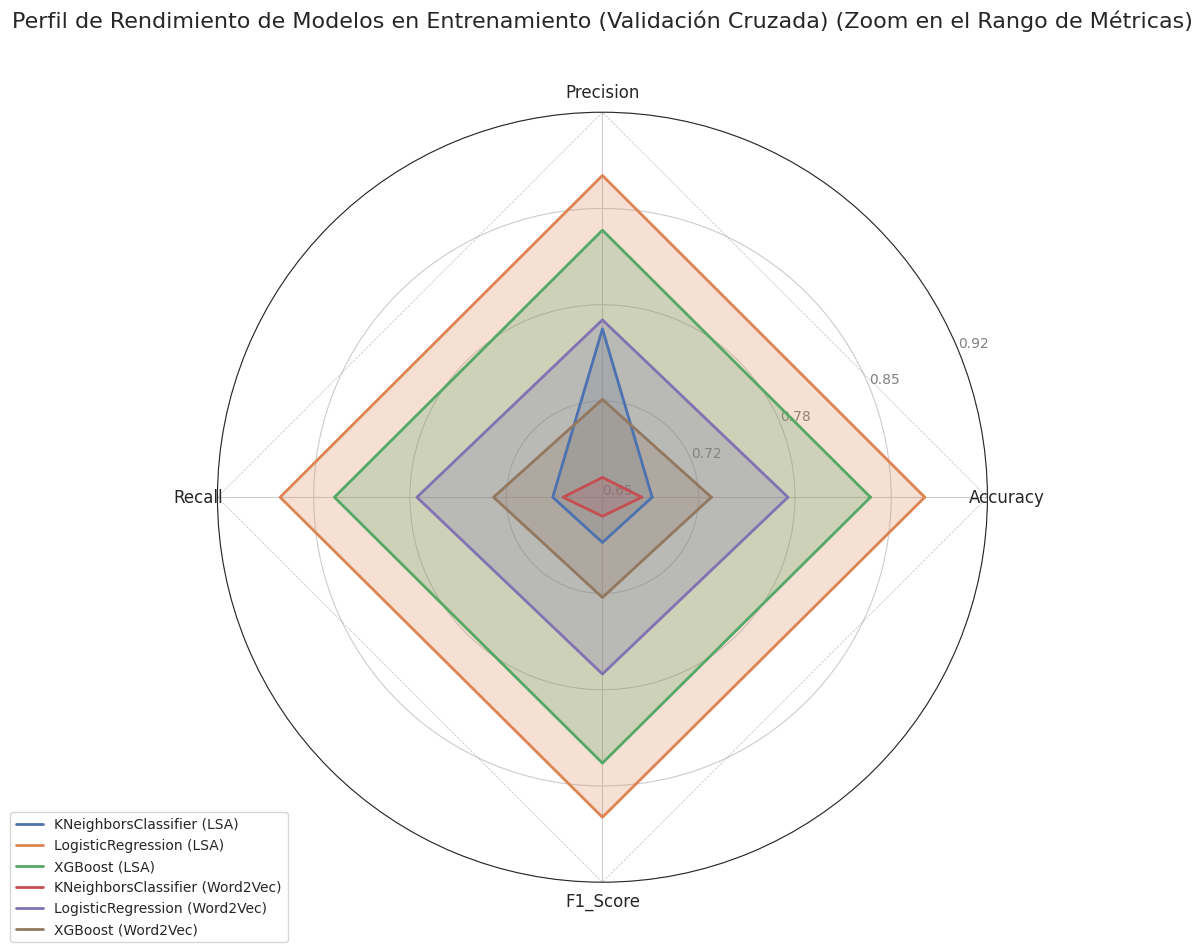

Generando Gráfica de Radar para Prueba (Test)...


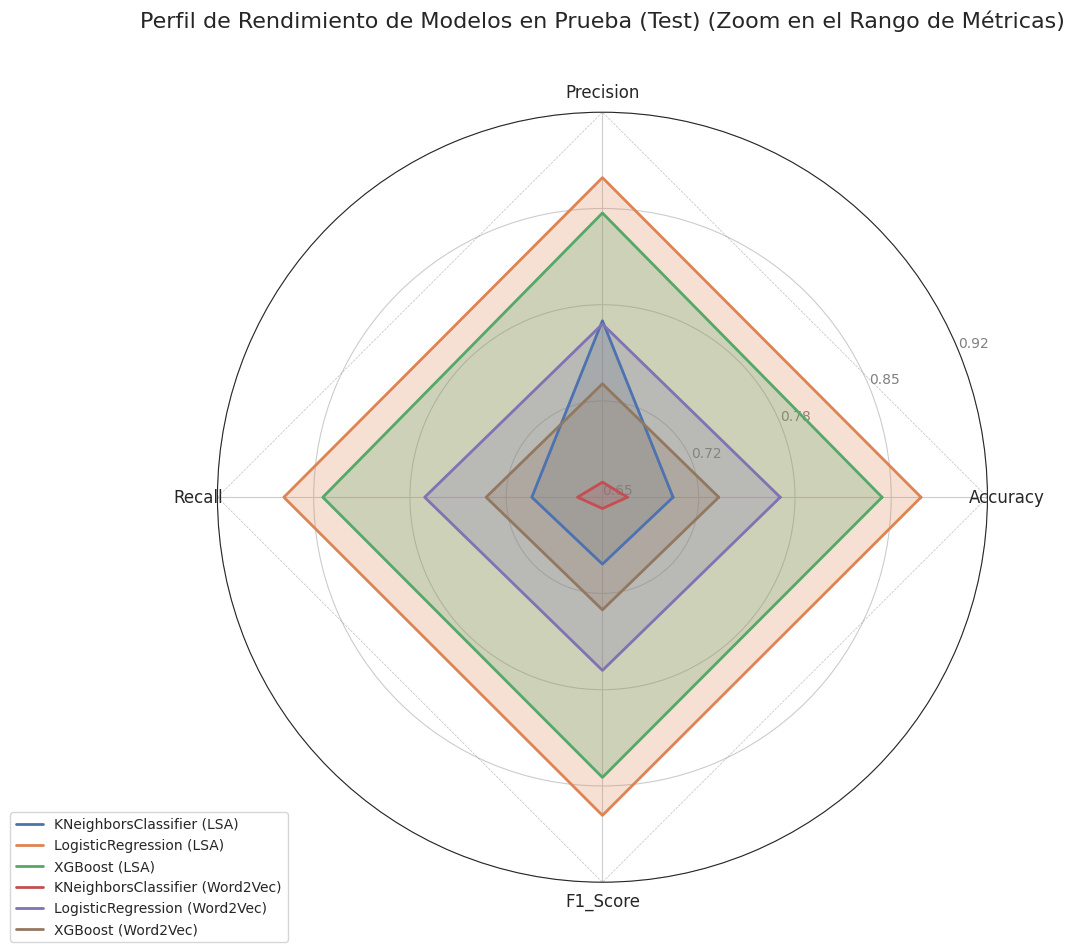

In [64]:
# Generación de gráfica de radar para ánalisis de resultados de los modelos de entrenamiento y prueba

def generar_grafica_radar(df_data, titulo_sufijo, lower_ylim, upper_ylim):
    """
    Genera y muestra una gráfica de radar para el conjunto de datos proporcionado.
    """
    metricas = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
    N = len(metricas)

    # Preparación de datos y ángulos
    # Nota: Usamos .copy() para evitar SettingWithCopyWarning
    df_data['Opción'] = df_data['Modelo'] + ' (' + df_data['Matriz'].str.replace('TF-IDF + SVD', 'LSA') + ')'
    modelos = df_data['Opción'].unique()

    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    # Configuración de la gráfica
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    ax.set_ylim(lower_ylim, upper_ylim)

    # Círculo exterior (representa el upper_ylim)
    ax.plot(angulos, [upper_ylim] * (N + 1), color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Dibujar los perfiles de cada modelo
    colores = sns.color_palette("deep", len(modelos))

    for i, modelo in enumerate(modelos):
        valores_serie = df_data[df_data['Opción'] == modelo][metricas].iloc[0]
        valores = valores_serie.tolist()
        valores += valores[:1]

        ax.plot(angulos, valores, linewidth=2, linestyle='solid',
                 label=modelo, color=colores[i])
        ax.fill(angulos, valores, alpha=0.25, color=colores[i])

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(metricas, fontsize=12)

    # Ajustes finales a la gráfica
    num_ticks = 5
    yticks = np.linspace(lower_ylim, upper_ylim, num_ticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.2f}" for y in yticks], color="grey", size=10)

    plt.title(f'Perfil de Rendimiento de Modelos en {titulo_sufijo} (Zoom en el Rango de Métricas)', size=16, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=10)

    plt.show()

# 1. Definición de rango
todas_las_metricas = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
min_val_global = df_final[todas_las_metricas].min().min()
max_val_global = df_final[todas_las_metricas].max().max()

# Ajustar límites (mínimo * 0.95 y máximo * 1.05)
# Usamos max(0.65, ...) para que la gráfica no se vea demasiado pequeña si los valores son altos.
lower_ylim_global = max(0.65, min_val_global * 0.95)
upper_ylim_global = min(1.0, max_val_global * 1.05)


# Desarrollo de gráfica para modelo de entrenamiento (Train)
df_cv = df_final[df_final['Conjunto'] == 'Entrenamiento'].copy()
print("Generando Gráfica de Radar para Validación Cruzada...")
generar_grafica_radar(df_cv, 'Entrenamiento (Validación Cruzada)', lower_ylim_global, upper_ylim_global)

# Desarrollo de gráfica para modelo de prueba (Test)
df_prueba = df_final[df_final['Conjunto'] == 'Prueba (Test)'].copy()
print("Generando Gráfica de Radar para Prueba (Test)...")
generar_grafica_radar(df_prueba, 'Prueba (Test)', lower_ylim_global, upper_ylim_global)

**Analisis de métricas:**
Las conclusiones de este análisis son bajo el desarrollo de un pipeline principal que toma una matriz de 300 componentes para cada técnica

*   El diagrama de radar nos muestra que el modelo que presenta un mejor desempeño es Regresión Logística con la matriz TF-IDF+SVD. Los resultados de las cuatro métricas evaluadas cubren la mayor proporción del poligono indicando que este modelo es el mejor en cada uno de los scores evaluados.
*   El hecho que el polígono presente una forma simétrica en sus dos ejes nos indica un balance entre las métricas: accuracy - recall y precision - f1. Lo anterior indica que el modelo no acierta solo en lo general sino que es capaz de identificar instancias relevantes, aun si las mismas no son frecuentes (balance entre accuracy - recall). Adicionalmente, significa que el modelo predice con exactitud (pocas falsas alarmas) y al mismo tiempo mantiene una capacidad razonable de cobertura sobre los casos relevantes (balance entre f1 y precision)
*   Se destaca dentro del grafico el comportamiento irregular del modelo KNN con matriz TF-IDF+SVD, ya que presenta una forma alargada indicando alta precisión y bajo recall, indicando que el modelo es capaz de predecir de manera correcta para las clases de mayor representación pero se queda corto con aquellas clases inferiores, siendo asi un modelo conservador que solo acierta cuando esta seguro del resultado.
*   Para el modelo de regresión logística encontramos que los resultados de los score para pruebas y entrenamiento presentan valores similares (f1 test = 0.8709 y f1 train = 0.8733) esto es un claro indicio de capacidad de generalización del modelo.
*   Los resultados muestran que XGBoost ofrece un desempeño muy similar al de la Regresión Logística, pero con un costo computacional considerablemente mayor. La mínima diferencia en métricas no compensa el incremento en complejidad y recursos necesarios para su entrenamiento y ajuste, y además, frente a la claridad interpretativa de la Regresión Logística, XGBoost resulta menos transparente. En este escenario, por tanto, no se justifica su elección como modelo final, ya que no aporta ventajas sustanciales en rendimiento y penaliza tanto en eficiencia como en interpretabilidad.
*   De manera general, la tabla y los resultados muestran que los modelos presentan un mejor desempeño con la representación TF-IDF+SVD en comparación con Word2Vec. Esto puede explicarse porque TF-IDF pondera la importancia relativa de las palabras en el corpus y, al combinarse con SVD, concentra la información en un espacio reducido y más discriminativo. De esta manera, los clasificadores logran identificar con mayor claridad las palabras que caracterizan cada tópico y asociarlas a sus etiquetas correspondientes.








**Analisis de Varianza:**

Como se ha explicado y justificado con anterioridad la selección del mejor modelo se realizó tomando un espacio o matriz de 300 componentes. Este numero de componentes no es el parámetro que garantiza la mejor varianza. Por ello presentamos el siguiente cálcuo para determinar a través de una curva del codo el volumen de componentes para el 90% de la varianza:

In [90]:
# Desarrollo de pipeline NLP utilizando matriz TF-IDF + SVD con n_components = 3000 a fin de evaluar el mejor hiperparámetro que nos garantiza el 90% de la varianza

n_componentes1 = 3000
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Definición del pipeline TF-IDF + SVD
pipeline_svd_3k = Pipeline([
    ('limpieza', FunctionTransformer(limpiar_texto)),
    ('preprocesamiento', FunctionTransformer(preprocesar_y_normalizar)),
    ('tfidf', TfidfVectorizer(use_idf=True, norm='l2', smooth_idf=True)),
    ('svd', TruncatedSVD(n_components=n_componentes1, random_state=42)),
    ('classifier', LogisticRegression(C=8, solver='liblinear', max_iter=500, random_state=42)) # Mejores hiperparámetros encontrados en pipeline de 300 componentes
])

model_reg = pipeline_svd_3k.fit(x_train_reg, y_train_reg)

In [94]:
# Aplicamos el pipeline a la columna de texto
y_pred_reg = model_reg.predict(x_train_reg)

accuracy_reg = accuracy_score(y_train_reg, y_pred_reg)
print(f"Accuracy en el conjunto de entrenamiento: {accuracy_reg:.4f}")
f1_reg = f1_score(y_train_reg, y_pred_reg, average='weighted')
print(f"F1-Score en el conjunto de entrenamiento: {f1_reg:.4f}")
recall_reg = recall_score(y_train_reg, y_pred_reg, average='weighted')
print(f"Recall en el conjunto de entrenamiento: {recall_reg:.4f}")
precision_reg = precision_score(y_train_reg, y_pred_reg, average='weighted')
print(f"Precision en el conjunto de entrenamiento: {precision_reg:.4f}")

y_pred_test_reg = model_reg.predict(x_test_reg)

accuracy_reg = accuracy_score(y_test_reg, y_pred_test_reg)
print(f"Accuracy en el conjunto de prueba: {accuracy_reg:.4f}")
f1_reg = f1_score(y_test_reg, y_pred_test_reg, average='weighted')
print(f"F1-Score en el conjunto de prueba: {f1_reg:.4f}")
recall_reg = recall_score(y_test_reg, y_pred_test_reg, average='weighted')
print(f"Recall en el conjunto de prueba: {recall_reg:.4f}")
precision_reg = precision_score(y_test_reg, y_pred_test_reg, average='weighted')
print(f"Precision en el conjunto de prueba: {precision_reg:.4f}")


Accuracy en el conjunto de entrenamiento: 0.9894
F1-Score en el conjunto de entrenamiento: 0.9894
Recall en el conjunto de entrenamiento: 0.9894
Precision en el conjunto de entrenamiento: 0.9895
Accuracy en el conjunto de prueba: 0.8886
F1-Score en el conjunto de prueba: 0.8885
Recall en el conjunto de prueba: 0.8886
Precision en el conjunto de prueba: 0.8896


Como resultado del incremento del número de componentes de 300 a 3000 para el modelo de regresión lineal vemos como se incrementaron todas las métricas en un importante porcentaje:

Metricas de entrenamiento
*   Accuracy: 0.8750 -> 0.9894
*   F1: 0.8734 -> 0.9894
*   Precision:0.8746 -> 0.9895
*   Recall: 0.8750 -> 0.9894

Metricas de Test
*   Accuracy: 0.8724 -> 0.8886
*   F1: 0.8721 -> 0.8885
*   Precision:0.8731 -> 0.8896
*   Recall: 0.8724 -> 0.8886

Encontramos que el modelo presenta un buen desempeño general, logrando un 88-89% en métricas clave sobre el conjunto de prueba, lo que muestra su capacidad generaliza.

Sin embargo, encontramos un ligero sobreajuste, con una diferencia de  aproximadamente de 0.10 (10 puntos) entre entrenamiento y prueba, lo cual indica que el modelo aprendió muy bien los datos de entrenamiento pero perdió algo de capacidad de generalización.

Tambien es notorio el balance entre métricas: como Precision, Recall y F1 están casi iguales en ambos sets, con lo cual podemos concluir que el modelo no favorece en exceso ni la precisión ni la cobertura (equilibrio sano).

Finalmente presentamos el análisis de variación de componentes y su impacto en la varianza acumulada para el mejor modelo:

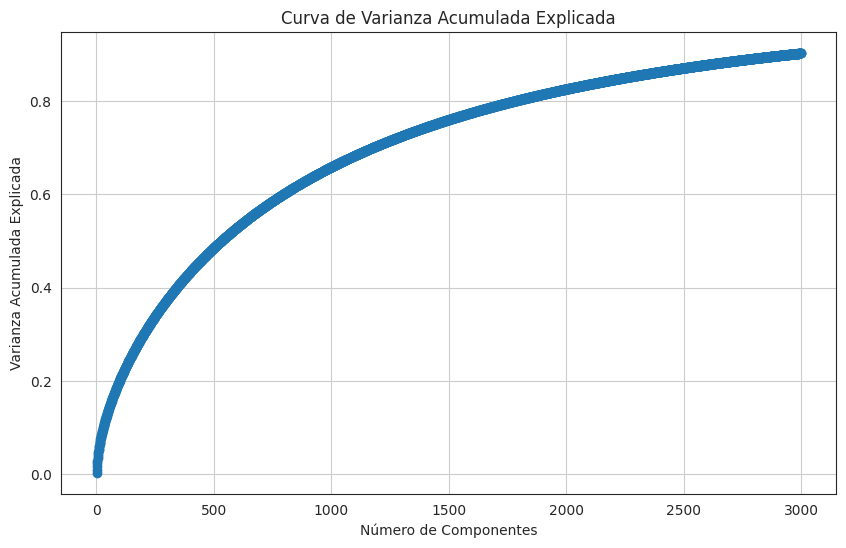

El 90% de la varianza se explica con 2945 componentes.


In [85]:
# Generación de gráfico de varianza para determinar número óptimo de componentes SVD
tsvd_3k = pipeline_svd_3k.named_steps['svd']

# Cálculo de varianza explicada y acumulada
varianza_explicada = tsvd_3k.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Dibujo de diagrama de codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_componentes1 + 1), varianza_acumulada, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Curva de Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Cálculo del numero de componentes mínimos para garantizar el 90% de la varianza
n_componentes_90_porciento = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"El 90% de la varianza se explica con {n_componentes_90_porciento} componentes.") # Hacer grafica de T-SNE para ver represtacion de datos de salida de svd.

Se determinó que con 2.945 componentes se alcanza el 90% de la varianza acumulada. En este sentido, el hiperparámetro de 3.000 componentes evaluado previamente constituye una opción adecuada para el preprocesamiento de datos, al garantizar un equilibrio entre capacidad explicativa y eficiencia del modelo.  

##**4. Evidencia de desempeño del método**

In [103]:
# Selecciona la clave del modelo con mejor rendimiento en Prueba (Test).

MEJOR_MODELO_KEY = 'LogisticRegression_TF-IDF + SVD'
mejor_modelo = best_models[MEJOR_MODELO_KEY]

preprocesador_matriz = pipeline_svd

def realizar_inferencia(texto, modelo, preprocesador, label_encoder):
    print(f"\n--- Clasificando el texto: '{texto[:50]}...' ---")

    # Preprocesamiento: Convertir el texto a la matriz de características esperada
    X_nuevo_list = [texto]
    X_nuevo_series = pd.Series(X_nuevo_list)

    # Usamos el preprocesador (transformador) para obtener la matriz de entrada.
    X_nuevo = preprocesador.transform(X_nuevo_series)

    # Predicción de la Clase (Devuelve un número de 0 a 15)
    prediccion_numerica = modelo.predict(X_nuevo)[0]

    # Probabilidades: Obtener las probabilidades para todas las clases
    probabilidades = modelo.predict_proba(X_nuevo)[0]

    # Invertir la codificación (Devuelve la etiqueta de texto original)
    prediccion_etiqueta = label_encoder.inverse_transform([prediccion_numerica])[0]

    # Generar un DataFrame con las probabilidades para mejor visualización
    df_probabilidades = pd.DataFrame({
        'Etiqueta_Numerica': range(len(probabilidades)),
        'Etiqueta_Clase': label_encoder.classes_,
        'Probabilidad': probabilidades.round(4)
    }).sort_values(by='Probabilidad', ascending=False)

    return {
        'Texto': texto,
        'Predicción_Etiqueta': prediccion_etiqueta,
        'Predicción_Numerica': prediccion_numerica,
        'Probabilidades_Detalle': df_probabilidades
    }

# Ejemplo 1: Documento de prueba proveniente del set de datos de inferencia no usados en etapa de entrenamiento o prueba.

idx_random = random.randint(0, 96) # ya que el set de datos de inferencia contiene 97 datos
texto_ejemplo_1 = x_inference.iloc[idx_random]
etiqueta_ejemplo_1 = y_inference.iloc[idx_random]

# Ejemplo 2: Documento de prueba proveniente del set de datos de inferencia no usados en etapa de entrenamiento o prueba.

idx_random = random.randint(0, 96) # ya que el set de datos de inferencia contiene 97 datos
texto_ejemplo_2 = x_inference.iloc[idx_random]
etiqueta_ejemplo_2 = y_inference.iloc[idx_random]

# Realizar la inferencia

resultado_1 = realizar_inferencia(texto_ejemplo_1, mejor_modelo, preprocesador_matriz, le)
resultado_2 = realizar_inferencia(texto_ejemplo_2, mejor_modelo, preprocesador_matriz, le)

# Imprimir resultados
print("\n" + "="*70)
print(f"RESULTADO DE LA INFERENCIA 1 (con datos no utilizados durante el entrenamiento del modelo):")
print(f"Texto: {resultado_1['Texto'][:100]}...")
print(f"Predicción Final: {resultado_1['Predicción_Etiqueta']} (Clase {resultado_1['Predicción_Numerica']})")
print(f"Etiqueta original (true value): {etiqueta_ejemplo_1} ")
print("-" * 70)
print("TOP 5 PROBABILIDADES:")
print(resultado_1['Probabilidades_Detalle'].head().to_markdown(index=False))

print("\n" + "="*70)
print(f"RESULTADO DE LA INFERENCIA 2 (con datos no utilizados durante el entrenamiento del modelo):")
print(f"Texto: {resultado_2['Texto'][:100]}...")
print(f"Predicción Final: {resultado_2['Predicción_Etiqueta']} (Clase {resultado_2['Predicción_Numerica']})")
print(f"Etiqueta original (true value): {etiqueta_ejemplo_2} ")
print("-" * 70)
print("TOP 5 PROBABILIDADES:")
print(resultado_2['Probabilidades_Detalle'].head().to_markdown(index=False))
print("="*70 + "\n")


--- Clasificando el texto: 'Los principales actores (instituciones, agencias, ...' ---

--- Clasificando el texto: 'Tales leyes también son causa de apatridia. Si la ...' ---

RESULTADO DE LA INFERENCIA 1 (con datos no utilizados durante el entrenamiento del modelo):
Texto: Los principales actores (instituciones, agencias, organizaciones y personas afectadas por la presenc...
Predicción Final: 15 (Clase 14)
Etiqueta original (true value): 15 
----------------------------------------------------------------------
TOP 5 PROBABILIDADES:
|   Etiqueta_Numerica |   Etiqueta_Clase |   Probabilidad |
|--------------------:|-----------------:|---------------:|
|                  14 |               15 |         0.8186 |
|                  10 |               11 |         0.0621 |
|                   2 |                3 |         0.0358 |
|                   5 |                6 |         0.0159 |
|                   8 |                9 |         0.011  |

RESULTADO DE LA INFERENCIA 2 (con dato

##**5. Conclusiones**


1.   Aunque Word2Vec permite capturar una semántica más rica a nivel de palabra, los resultados muestran que la representación mediante SVD o LSA (Análisis Semántico Latente) se adapta mejor a la tarea de clasificación de tópicos con modelos lineales como la Regresión Logística. Esto se debe a que, por su naturaleza, LSA transforma la información contenida en la matriz de términos en un espacio reducido y altamente discriminativo, donde los vectores resultantes están directamente orientados a maximizar la separación entre clases. En consecuencia, los modelos entrenados con SVD logran un desempeño más consistente y efectivo que aquellos basados en embeddings promedio de Word2Vec, los cuales, si bien son más expresivos semánticamente, tienden a diluir información relevante para la clasificación.
2.   El rendimiento relativamente bajo de Word2Vec en esta tarea puede explicarse en parte porque, al eliminar stopwords y signos de puntuación, se reduce la riqueza contextual de los textos. Word2Vec aprende representaciones semánticas a partir de las relaciones de co-ocurrencia entre palabras, por lo que elementos aparentemente triviales como las stopwords o incluso la puntuación aportan información sobre la estructura y el flujo del lenguaje. Al privarlo de estas señales, el modelo pierde parte de su capacidad para capturar relaciones semánticas sutiles, lo que limita su efectividad en la representación del corpus frente a métodos como SVD, que no dependen en la misma medida de estos contextos locales.
3.   Como propuesta de mejora, se sugiere explorar el uso de modelos no lineales, en particular Support Vector Machines (SVM) con kernels adecuados, sobre las representaciones generadas por Word2Vec. Dado que los embeddings capturan relaciones semánticas complejas y no estrictamente lineales, un clasificador más flexible como SVM podría explotar de manera más efectiva esta estructura, mejorando el desempeño en comparación con modelos lineales como la Regresión Logística.
